In [6]:
import os
import re
import math
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

# User data directory path
user_data_dir = "../../../USER_DATA/"

# Match format like: USER_1_TRADITIONAL.csv or USER_2_BUBBLE.csv
pattern = re.compile(r'USER_(\d+)_(TRADITIONAL|BUBBLE)\.csv', re.IGNORECASE)

In [7]:
# Map used to group each user's QWERTY/SWIPE trials
avg_user_data = {}

# Trial #:
#   {
#     (USER_X, BUBBLE)     :  { Column Averages }
#     (USER_X, TRADITONAL) :  { Column Averages }
#   }

# Parse all CSVs 
for filename in os.listdir(user_data_dir):
    match = pattern.match(filename)
    if match:
        user_id, method = match.groups()
        
        # Key is (USER_X, BUBBLE) or (USER_X, TRADITIONAL)
        user_key = (f"USER_{user_id}", method.upper())

        file_path = os.path.join(user_data_dir, filename)
        df = pd.read_csv(file_path)

        # Dict of averaged column values -> { column_name: average_value }
        numeric_avg = df.select_dtypes(include="number").mean()

        # Add the user metric values to the map
        if user_key not in avg_user_data:
            avg_user_data[user_key] = numeric_avg

In [8]:
# Build summary rows
percentage_metrics = [
        "netDeselectRate",
        "targetDeselectRate",
        "netAccuracy",
]

summary_rows = []
for (user, method), numeric_avg in avg_user_data.items():
        # Create row dictionary with averaged metrics with user and method
        row = numeric_avg.to_dict()

        # Convert to percentage if the column deals with rate
        for item in row.keys():
            if item in percentage_metrics:
                row[item] = round(row[item] * 100, 2)
            # Round all other values to 2 decimal places
            else:
                row[item] = round(row[item], 2)
        row["User"] = user
        row["Method"] = method
        summary_rows.append(row)

# Create DataFrame and reorder columns
summary_df = pd.DataFrame(summary_rows)
summary_df = summary_df[["User", "Method"] + [col for col in summary_df.columns if col not in ["User", "Method"]]]
summary_df = summary_df.drop(columns = ["trialNumber", "startTime", "endTime"])

summary_df = summary_df.rename(
     columns={
                "totalItemCount": "Total Item Count",
                "targetCount": "Target Count",
                "timeTaken": "Time Taken (s)", 
                "totalSelections": "Total Selections",
                "correctSelections": "Correct Selections",
                "incorrectSelections": "Incorrect Selections",
                "deselectedTargets": "Deselected Targets",
                "deselectedNonTargets": "Deselected Non-Targets",
                "totalCursorDistance": "Cursor Distance Traversed (px)",
                "netDeselectRate": "Net Deselect Rate (%)",
                "targetDeselectRate": "Target Deselect Rate (%)",
                "netAccuracy": "Net Accuracy (%)"
        }
)

# Verify summary_df is the data we need
print(summary_df)

      User       Method  Total Item Count  Target Count  Time Taken (s)  \
0   USER_1       BUBBLE             12.60          4.45            3.59   
1   USER_1  TRADITIONAL             12.50          4.85            3.54   
2   USER_2       BUBBLE             12.70          4.50            4.21   
3   USER_2  TRADITIONAL             12.90          4.80            3.03   
4   USER_3       BUBBLE             13.05          4.30            3.74   
5   USER_3  TRADITIONAL             12.60          4.55            3.03   
6   USER_4       BUBBLE             12.65          4.95            3.67   
7   USER_4  TRADITIONAL             11.60          4.70            3.59   
8   USER_5       BUBBLE             12.45          4.75            3.59   
9   USER_5  TRADITIONAL             12.80          4.65            3.09   
10  USER_6       BUBBLE             12.10          4.70            3.51   
11  USER_6  TRADITIONAL             12.15          4.55            3.12   

    Total Selections  Co

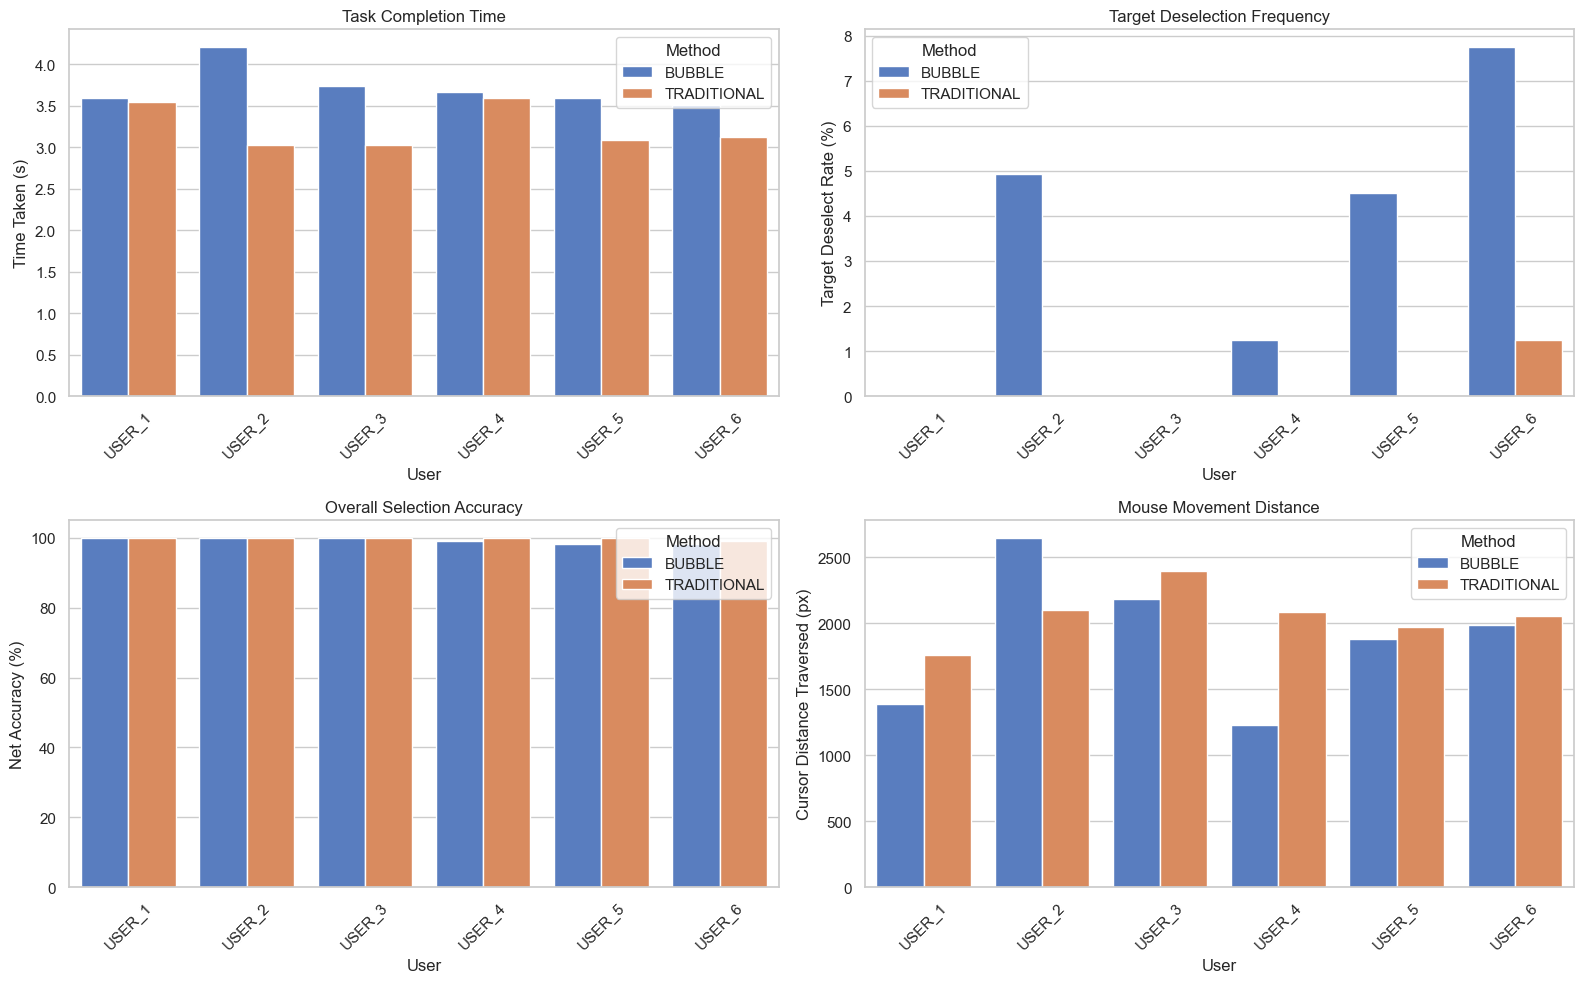

In [9]:
# Now we create visualizations using bar graph so each bar group is per 
# User with the 2 methods and the following metrics as the y-axis: Time Taken, Accuracy, Deselection Rate, and Total Cursor distance moved 
sns.set(style="whitegrid")

# Metrics that we will plot
metrics = [
    "Time Taken (s)",
    "Target Deselect Rate (%)", 
    "Net Accuracy (%)", 
    "Cursor Distance Traversed (px)"
]

title_map = {
    "Time Taken (s)": "Task Completion Time",
    "Target Deselect Rate (%)": "Target Deselection Frequency",
    "Net Accuracy (%)": "Overall Selection Accuracy",
    "Cursor Distance Traversed (px)": "Mouse Movement Distance"
}

fig, axes = plt.subplots(2, math.ceil(len(metrics) / 2), figsize=(16, 10))
axes = axes.flatten()

# Create one subplot per metric
for idx, metric in enumerate(metrics):
    ax = axes[idx]
    sns.barplot(
        data=summary_df,
        x="User",
        y=metric,
        hue="Method",
        ax=ax,
        palette="muted"
    )

    ax.set_title(title_map[metric])
    ax.set_ylabel(metric)
    ax.set_xlabel("User")
    ax.legend(title="Method")
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()